# Cosimita: the Earth albedo

Every source so far has been *out there* -- on the sky, or bolted to the
spacecraft. This one is underneath: gamma rays coming off the Earth itself.

It is a **stand-in for atmospheric scattering, not a real albedo model**. What
matters pedagogically is that it behaves unlike every other source in the
package:

- Its normalization is a **surface emissivity** `E` in `1/cm/s` -- photons per
  unit length of Earth surface per second, into the outward half-plane. That is
  a property of the *surface*, so the same source object means the same physics
  at any altitude, and the flux it delivers to the spacecraft falls off as you
  climb.
- It is the one far-field source whose `simulated_rate` **depends on the pose**,
  because how much sky the Earth fills depends on `orbit_radius`.
- It must **not** be occulted. Its photons all arrive from the Earth's
  direction, so a blanket "is this direction behind the Earth?" test would
  reject the entire source (plan Section 8, trap 1).

Two emission laws are available, and both can be used at once by putting two
sources in a run with their own emissivities:

- `'isotropic'` -- uniform over the outward half-plane, so `E/pi` per unit angle.
- `'lambertian'` -- proportional to `cos theta` from the local normal, giving a
  uniform-brightness disc.

In [1]:
from gammaraytoys import ToyTracker2D
from gammaraytoys.sims import (EarthAlbedoSource, PointSource, MonoenergeticSpectrum,
                               Earth, SpacecraftInterval, SpacecraftHistory,
                               ZenithPointing, InertialSimulator,
                               SimpleTraditionalReconstructor)
from histpy import Histogram, Axis
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

comptelito = ToyTracker2D(material = 'Ge',
                          layer_length = 10*u.m,
                          layer_positions = np.append(300, np.arange(0,10,1))*u.cm,
                          layer_thickness = 1*u.cm,
                          energy_resolution = 0.03,
                          energy_threshold = 20*u.keV)

# 6371 km, matching the rest of the cosimita notebooks. Note the *default*
# Earth() is astropy's nominal 6378.1 km -- close enough to look right and
# different enough to matter, so pass the same Earth everywhere explicitly.
earth = Earth(radius = 6371*u.km)
reco = SimpleTraditionalReconstructor()

emissivity = 1e-4/u.cm/u.s

def albedo(law, E = emissivity):
    return EarthAlbedoSource(emissivity = E, spectrum = MonoenergeticSpectrum(1*u.MeV),
                             law = law, earth = earth)

def pose_at(altitude, attitude):
    """A one-second pose at `altitude` above the surface, with a given attitude."""
    return SpacecraftInterval(start_time = 0*u.s, stop_time = 1*u.s, livetime = 1*u.s,
                              attitude = attitude, orbit_angle = 90*u.deg,
                              orbit_radius = earth.radius + altitude)

print(f"Earth radius {earth.radius},  emissivity {emissivity}")

Earth radius 6371.0 km,  emissivity 0.0001 1 / (cm s)


## 1. How much of it reaches you, and how that depends on altitude

The total launched rate has a closed form for the Lambertian law and a numeric
one for the isotropic law (plan Section 5.6):

```
lambertian:  N = 2 a E arcsin(R_E / r)
isotropic:   N = (2 a E R_E / pi) * integral[ 1/s(beta) ] dbeta
```

with `a` the detector's surrounding-circle radius and `s(beta)` the distance
from a surface point to the spacecraft. Both fall off as you climb, but not at
the same rate.

In [2]:
altitudes = np.array([100, 200, 400, 800, 2000, 6000, 20000, 100000])*u.km

rates = {law: u.Quantity([albedo(law).simulated_rate(comptelito,
                                                     pose_at(alt, 270*u.deg))
                          for alt in altitudes]).to(1/u.s)
         for law in ['lambertian', 'isotropic']}

# The Lambertian closed form, written out here rather than taken from the code.
a = comptelito.surrounding_circle_radius
# np.arcsin on a Quantity returns radians; the formula wants the plain
# number of radians, so strip the unit with .to_value(u.rad).
closed_form = (2*a*emissivity*
               np.arcsin(earth.radius/(earth.radius + altitudes)).to_value(u.rad)).to(1/u.s)

print(f"{'alt km':>9} {'lambertian':>14} {'2 a E arcsin(R/r)':>19} {'isotropic':>14} {'iso/lamb':>9}")
for i, alt in enumerate(altitudes):
    print(f"{alt.to_value(u.km):9.0f} {rates['lambertian'][i].value:14.6e} "
          f"{closed_form[i].value:19.6e} {rates['isotropic'][i].value:14.6e} "
          f"{(rates['isotropic'][i]/rates['lambertian'][i]).value:9.4f}")

   alt km     lambertian   2 a E arcsin(R/r)      isotropic  iso/lamb
      100   1.456177e-01        1.456177e-01   2.058116e-01    1.4134
      200   1.381713e-01        1.381713e-01   1.818024e-01    1.3158
      400   1.279303e-01        1.279303e-01   1.572160e-01    1.2289
      800   1.142101e-01        1.142101e-01   1.318953e-01    1.1548
     2000   9.030618e-02        9.030618e-02   9.751571e-02    1.0798
     6000   5.648222e-02        5.648222e-02   5.798726e-02    1.0266
    20000   2.547489e-02        2.547489e-02   2.560349e-02    1.0050
   100000   6.256877e-03        6.256877e-03   6.258752e-03    1.0003


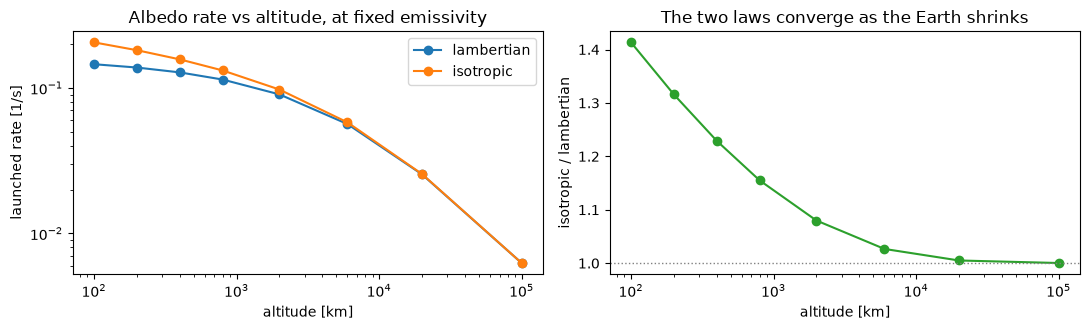

In [3]:
fig, ax = plt.subplots(figsize = (11, 3.4), ncols = 2)

for law, colour in [('lambertian', 'tab:blue'), ('isotropic', 'tab:orange')]:
    ax[0].loglog(altitudes.to_value(u.km), rates[law].to_value(1/u.s),
                 'o-', color = colour, label = law)
ax[0].set_xlabel('altitude [km]'); ax[0].set_ylabel('launched rate [1/s]')
ax[0].set_title('Albedo rate vs altitude, at fixed emissivity')
ax[0].legend()

ax[1].semilogx(altitudes.to_value(u.km),
               (rates['isotropic']/rates['lambertian']).value, 'o-', color = 'tab:green')
ax[1].axhline(1.0, color = 'gray', ls = ':', lw = 1)
ax[1].set_xlabel('altitude [km]'); ax[1].set_ylabel('isotropic / lambertian')
ax[1].set_title('The two laws converge as the Earth shrinks')

fig.tight_layout()

The ratio is the interesting part. Close in, the isotropic law delivers
substantially more than the Lambertian one at equal emissivity; far out they
converge to 1. The reason is the **limb**: the isotropic law is limb-brightened
and the Lambertian one is not, and the limb is a large fraction of the visible
disc only when the Earth is large in your sky. From far away the Earth is a
point and it stops mattering which law painted it.

## 2. Where the photons come from, and why the sampler works in `beta`

Both laws send photons from within `rho = arcsin(R_E/r)` of nadir. What differs
is how they fill that disc.

   lambertian: max |offset| =  70.206 deg   (rho = 70.207)
    isotropic: max |offset| =  70.207 deg   (rho = 70.207)


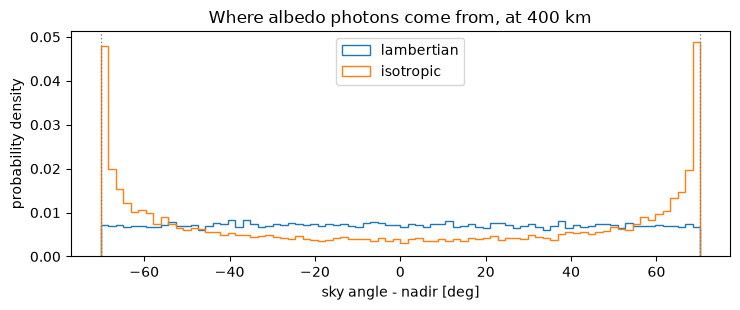

In [4]:
altitude = 400*u.km
nadir_pose = pose_at(altitude, 270*u.deg)      # attitude = orbit_angle + 180: nadir on-axis
rho = np.degrees(np.arcsin((earth.radius/(earth.radius + altitude)).value))

def drawn_offsets_from_nadir(source, n, seed = 1):
    """Sky angles of `n` photons, as an offset from nadir in degrees.

    `random_photon` returns a detector-frame direction; the conventions chain
    as direction = 270 deg - Nu and Nu = A - lambda, so
    lambda = A - (270 deg - direction). Nadir sits at orbit_angle + 180 deg.
    """
    np.random.seed(seed)
    attitude = nadir_pose.attitude.to_value(u.deg)
    nadir = (nadir_pose.orbit_angle.to_value(u.deg) + 180) % 360
    lam = np.array([attitude - (270 - source.random_photon(comptelito, nadir_pose, earth)
                                            .direction.to_value(u.deg))
                    for _ in range(n)])
    return (lam - nadir + 180) % 360 - 180

offsets = {law: drawn_offsets_from_nadir(albedo(law), 20000) for law in ['lambertian','isotropic']}

fig, ax = plt.subplots(figsize = (7.5, 3.2))
for law, colour in [('lambertian','tab:blue'), ('isotropic','tab:orange')]:
    ax.hist(offsets[law], bins = 80, range = (-rho, rho), histtype = 'step',
            density = True, color = colour, label = law)
    print(f"  {law:>11}: max |offset| = {np.abs(offsets[law]).max():7.3f} deg   (rho = {rho:.3f})")
for edge in (-rho, rho):
    ax.axvline(edge, color = 'gray', ls = ':', lw = 1)
ax.set_xlabel('sky angle - nadir [deg]'); ax.set_ylabel('probability density')
ax.set_title(f'Where albedo photons come from, at {altitude:.0f}')
ax.legend()
fig.tight_layout()

The Lambertian disc is **flat** -- uniform in sky angle, which is exactly what a
uniform-brightness disc looks like, and why the implementation samples it by
drawing uniformly on `[nadir - rho, nadir + rho]` and skipping all the surface
machinery. The isotropic disc is **limb-brightened**: it piles up at the edges.

That pile-up is the reason for the one piece of the sampler that looks
over-engineered. The isotropic brightness goes as `1/cos theta`, where `theta`
is the emission angle at the *surface point*. At the visible limb the line of
sight is tangent to the surface, so `theta` is exactly 90 degrees and
`cos theta` is exactly zero -- **at every altitude**, not just low ones. Climbing
higher shrinks the Earth's apparent radius `rho` but does not remove the
divergence.

So the sampler works in `beta`, the Earth-central angle of the emission point,
where the surface measure cancels the divergence and the density
`pdf(beta) ~ 1/s(beta)` is smooth and bounded. Section 5.6 of the plan is
emphatic about not "simplifying" this back into sky-angle space.

  cos(theta) at the limb   = 0.000e+00   (a 1/cos divergence, at any altitude)
  min s(beta)              = 400.0 km = r - R_E, so 1/s is bounded by 2.500e-03


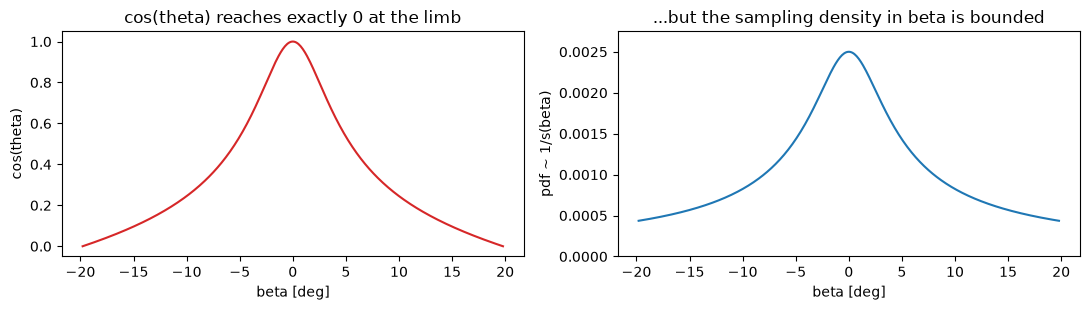

In [5]:
R, r = earth.radius.to_value(u.km), (earth.radius + altitude).to_value(u.km)
beta_max = np.arccos(R/r)
beta = np.linspace(-beta_max, beta_max, 400)
s = np.sqrt(r**2 + R**2 - 2*r*R*np.cos(beta))
cos_theta = (r*np.cos(beta) - R)/s

fig, ax = plt.subplots(figsize = (11, 3.2), ncols = 2)

ax[0].plot(np.degrees(beta), cos_theta, color = 'tab:red')
ax[0].set_xlabel('beta [deg]'); ax[0].set_ylabel('cos(theta)')
ax[0].set_title('cos(theta) reaches exactly 0 at the limb')

ax[1].plot(np.degrees(beta), 1/s, color = 'tab:blue')
ax[1].set_ylim(0, 1.1*(1/s).max())
ax[1].set_xlabel('beta [deg]'); ax[1].set_ylabel('pdf ~ 1/s(beta)')
ax[1].set_title('...but the sampling density in beta is bounded')

fig.tight_layout()
print(f"  cos(theta) at the limb   = {cos_theta[0]:.3e}   (a 1/cos divergence, at any altitude)")
print(f"  min s(beta)              = {s.min():.1f} km = r - R_E, so 1/s is bounded by "
      f"{1/s.min():.3e}")

## 3. The Earth is not an occulter of itself

Every other far-field source is discarded when the Earth is between it and the
spacecraft. Applying that test here would reject **every** albedo photon, since
they all arrive from inside `rho` of nadir by construction. So
`EarthAlbedoSource.occultable` is `False`, and the Earth's shadowing of its own
far side is handled where it belongs -- in the sampling, which only ever draws
surface points actually visible from the spacecraft (`|beta| < beta_max`).

Run it against a sky source to see both behaviours at once.

In [6]:
history = SpacecraftHistory.from_elliptical_orbit(semi_major_axis = earth.radius + altitude,
                                                  duration = 6000*u.s, time_step = 60*u.s,
                                                  earth = earth,
                                                  observation_strategy = ZenithPointing())

albedo_source = albedo('isotropic')
sky_source = PointSource(sky_angle = 40*u.deg,
                         spectrum = MonoenergeticSpectrum(1*u.MeV),
                         flux = 2e-4/u.cm/u.s)

simulator = InertialSimulator(detector = comptelito,
                              sources = [albedo_source, sky_source],
                              reconstructor = reco,
                              spacecraft_history = history,
                              earth = earth)

np.random.seed(2)
events = list(simulator.run_events(progress = False))

launched = {'albedo': 0, 'sky': 0}
for _, source, _, _ in events:
    launched['albedo' if source is albedo_source else 'sky'] += 1

print(f"  albedo launched : {launched['albedo']}")
print(f"  sky launched    : {launched['sky']}")
print(f"  occulted (all sources, and all of them the sky source): {simulator.noccult}")
print(f"\n  the albedo lost none of its photons to occultation, as it must not")

  albedo launched : 987
  sky launched    : 809
  occulted (all sources, and all of them the sky source): 417

  the albedo lost none of its photons to occultation, as it must not


## 4. What the albedo looks like in the data

A caveat that matters more than it looks: **COMPTELito is a tracker-on-top
instrument**, and `SimpleTraditionalReconstructor` requires the first hit in
layer 0 with a calorimeter below it. A zenith-pointing spacecraft therefore
meets the albedo *from behind*, and records far less of it than a nadir-pointing
one would -- the same directional-acceptance effect notebook 03's placement
gallery shows for near-field sources, and the plan's trap 9 for far-field ones.

In [7]:
zenith_pose = pose_at(altitude, 90*u.deg)      # attitude = orbit_angle: nadir at Nu = 180 deg

def trigger_fraction(source, pose, n = 1200, seed = 4):
    np.random.seed(seed)
    return sum(reco.reconstruct(comptelito.simulate_event(
                   source.random_photon(comptelito, pose, earth))).triggered
               for _ in range(n))/n

print(f"{'pointing':>18} {'law':>11} {'trigger fraction':>17}")
for label, pose in [('nadir-pointing', nadir_pose), ('zenith-pointing', zenith_pose)]:
    for law in ['lambertian', 'isotropic']:
        print(f"{label:>18} {law:>11} {trigger_fraction(albedo(law), pose)*100:16.2f}%")

          pointing         law  trigger fraction


    nadir-pointing  lambertian             7.67%


    nadir-pointing   isotropic             5.75%


   zenith-pointing  lambertian             0.83%


   zenith-pointing   isotropic             1.08%


   lambertian: 200 triggers from 2399 launched


    isotropic: 200 triggers from 3138 launched


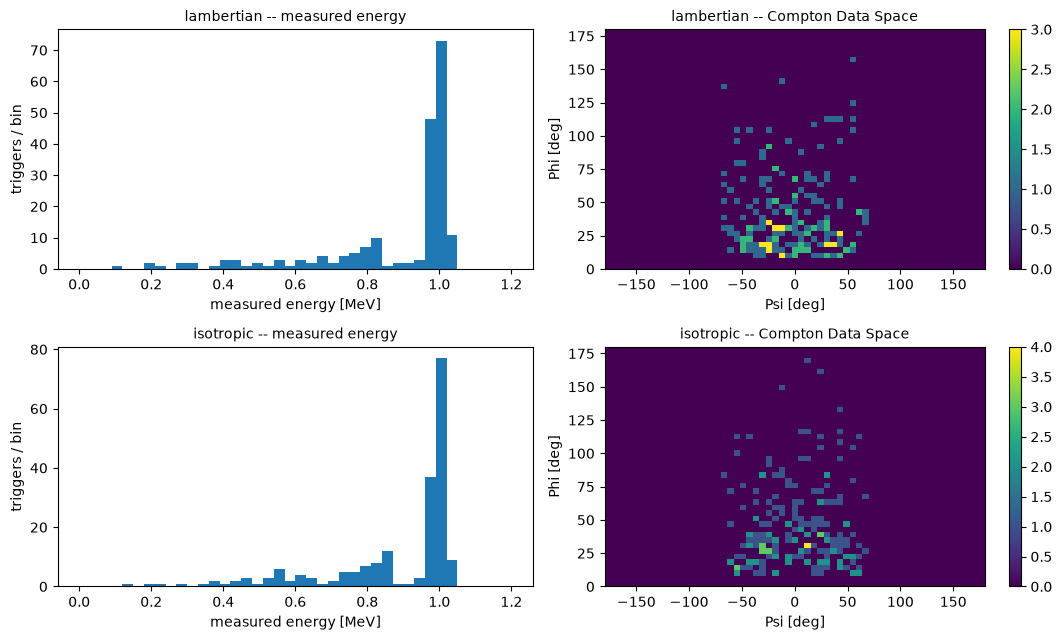

In [8]:
# Measured energy and Compton Data Space, nadir-pointing so there are enough
# triggers to see the structure without a long run.
def collect(source, pose, n_target = 200, max_launches = 20000, seed = 5):
    np.random.seed(seed)
    out, launched = [], 0
    while len(out) < n_target and launched < max_launches:
        launched += 1
        reco_event = reco.reconstruct(comptelito.simulate_event(
            source.random_photon(comptelito, pose, earth)))
        if reco_event.triggered:
            out.append(reco_event)
    return out, launched

phi_axis = Axis(np.linspace(0, 180, 45)*u.deg, label = 'Phi')
psi_axis = Axis(np.linspace(-180, 180, 60)*u.deg, label = 'Psi')

fig, ax = plt.subplots(figsize = (11, 6.5), nrows = 2, ncols = 2)

for row, law in enumerate(['lambertian', 'isotropic']):
    got, launched = collect(albedo(law), nadir_pose)
    print(f"  {law:>11}: {len(got)} triggers from {launched} launched")

    ax[row][0].hist(u.Quantity([e.energy for e in got]).to_value(u.MeV),
                    bins = 40, range = (0, 1.2), color = 'tab:blue')
    ax[row][0].set_xlabel('measured energy [MeV]'); ax[row][0].set_ylabel('triggers / bin')
    ax[row][0].set_title(f'{law} -- measured energy', fontsize = 10)

    h = Histogram([psi_axis, phi_axis])
    h.fill(u.Quantity([e.psi for e in got]).to(u.deg),
           u.Quantity([e.phi for e in got]).to(u.deg), warn_overflow = False)
    h.plot(ax[row][1])
    ax[row][1].set_title(f'{law} -- Compton Data Space', fontsize = 10)

fig.tight_layout()

## 5. Where it sits, drawn

`EarthAlbedoSource.plot` marks the Earth as an arc of the full apparent
diameter `2 rho`, centred on nadir -- the same `plot_sky_arc` primitive
`IsotropicSource` uses for the whole sky and `ExtendedSource` for its von Mises
width, just with the Earth's angular size instead.

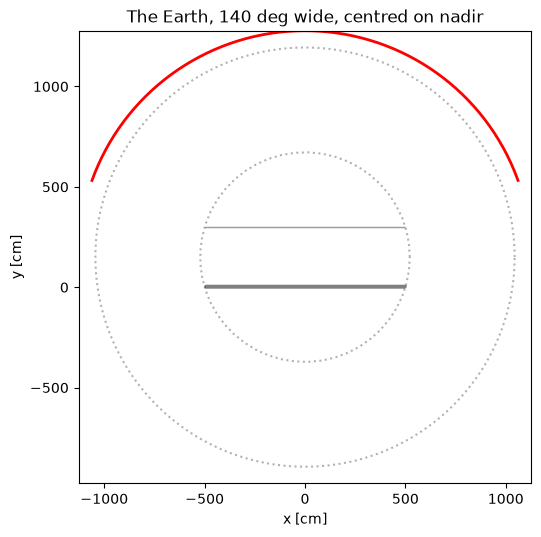

In [9]:
fig, ax = plt.subplots(figsize = (5.5, 5.5))
comptelito.plot(ax = ax, draw_surrounding_circle = True)

source = albedo('isotropic')
source.random_photon(comptelito, nadir_pose, earth)   # plot needs a pose to have been seen
source.plot(ax, comptelito)

ax.set_title(f'The Earth, {2*rho:.0f} deg wide, centred on nadir')
fig.tight_layout()

The arc spans the whole visible Earth. At 400 km that is most of one side of the
sky -- which is the real lesson of this notebook. The albedo is not a source you
can point away from: it is a floor under everything else the instrument sees,
and its size is set by your altitude, not by anything you control.